In [1]:
### import libraries
import os
import pathlib
import requests
import zipfile
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
from glob import glob
import time
import pandas as pd

### gbif packages
import pygbif.occurrences as occ
import pygbif.species as species
from getpass import getpass

In [2]:
### set up file paths
data_dir = os.path.join(
    pathlib.Path.home(),
    'earth-analytics',
    'data',
    'grasslands'
)

os.makedirs(data_dir, exist_ok=True)

In [3]:
### set a directory for the National Grassland boundary data
boundary_dir = os.path.join(data_dir, 'NG_boundary')

In [4]:
### set the data download URL
boundary_url = "https://data.fs.usda.gov/geodata/edw/edw_resources/shp/BdyDesg_LSRS_NationalGrassland.zip"

# path where zip will be saved
boundary_path = os.path.join(data_dir, "national_grassland.zip")

# download file
response = requests.get(boundary_url, stream=True)
response.raise_for_status()

with open(boundary_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Downloaded to: {boundary_path}")

Downloaded to: C:\Users\warno\earth-analytics\data\grasslands\national_grassland.zip


In [5]:
# make sure boundary_dir exists
os.makedirs(boundary_dir, exist_ok=True)

### unzip the file
with zipfile.ZipFile(boundary_path, 'r') as zip_ref:
    zip_ref.extractall(boundary_dir)

print(f"Extracted to: {boundary_dir}")

Extracted to: C:\Users\warno\earth-analytics\data\grasslands\NG_boundary


In [6]:
### automatically check for .shp file name
shp_files = [f for f in os.listdir(boundary_dir) if f.endswith(".shp")]

shp_path = os.path.join(boundary_dir, shp_files[0])
boundary_gdf = gpd.read_file(shp_path)

In [7]:
# select only Pawnee National Grassland
pawnee = boundary_gdf[boundary_gdf["GRASSLANDN"] == "Pawnee National Grassland"].copy()

# check the result
pawnee

,NATIONALGR,GRASSLANDN,GIS_ACRES,SHAPE_AREA,SHAPE_LEN,geometry
0,295523010328,Pawnee National Grassland,208424.885,0.089972,15.341594,"MULTIPOLYGON (((-104.58106 40.82664, -104.5810..."


In [25]:
# path for new shapefile
pawnee_shp = os.path.join(boundary_dir, "pawnee_national_grassland.shp")

# write to shapefile
pawnee.to_file(pawnee_shp)

print(pawnee_shp)

INFO:Created 1 records


C:\Users\warno\earth-analytics\data\grasslands\NG_boundary\pawnee_national_grassland.shp


In [16]:
### path to master boundary for pawnee (custom)
pawnee_master_boundary = os.path.join(boundary_dir, "pawnee_master_boundary.shp")

print(pawnee_master_boundary)

C:\Users\warno\earth-analytics\data\grasslands\NG_boundary\pawnee_master_boundary.shp


In [19]:
# read shapefile into a GeoDataFrame
pawnee_master_boundary_gdf = gpd.read_file(pawnee_master_boundary)


<Axes: >

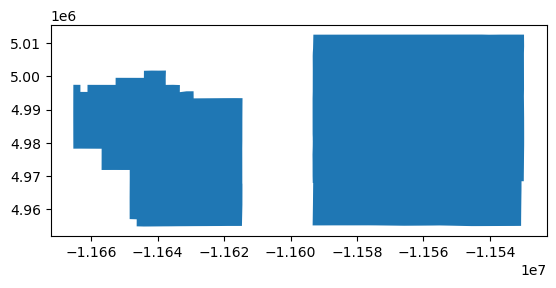

In [17]:
pawnee_master_boundary_gdf.plot()

In [36]:
pawnee.hvplot(
    geo = True,
    tiles = 'EsriImagery',
    title = 'Pawnee National Grassland Boundaries',
    fill_color = None,
    line_color = "white",
    frame_width = 600
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### GBIF Login

In [11]:
### reset credentials
reset_credentials = False

### make dictionary for GBIF username and pass
credentials = dict(
    GBIF_USER=(input, 'GBIF username:'),
    GBIF_PWD=(getpass, 'GBIF password'),
    GBIF_EMAIL=(input, 'GBIF email'),
)

### loop through credentials and enter them
for env_variable, (prompt_func, prompt_text) in credentials.items():

    if reset_credentials and (env_variable in os.environ):
        os.environ.pop(env_variable)

    if not env_variable in os.environ:
        os.environ[env_variable] = prompt_func(prompt_text)

### Download GBIF data for Prairie Dogs and Pronghorn

In [ ]:
### function to download GBIF data for Prairie Dogs and Pronghorn
def download_gbif_species(species_name, folder_name, data_dir):
    """
    Download one GBIF species file, extract it, and read it into a DataFrame.
    """
    ### search species in GBIF backbone
    species_info = species.name_backbone(name=species_name)

    ### get the usage key
    species_key = species_info["usageKey"]
    print(f"{species_name}: {species_key}")

    ### set species directory
    gbif_dir = os.path.join(data_dir, folder_name)
    os.makedirs(gbif_dir, exist_ok=True)

    ### make a file path pattern for data
    gbif_pattern = os.path.join(gbif_dir, "*.csv")

    ### download it once
    if not glob(gbif_pattern):

        ### submit query
        gbif_query = occ.download([
            f"speciesKey = {species_key}",
            "hasCoordinate = True",
        ])

        download_key = gbif_query[0]

        ### wait for the download to build
        wait = occ.download_meta(download_key)["status"]
        while wait != "SUCCEEDED":
            if wait in {"CANCELLED", "KILLED", "FAILED"}:
                raise RuntimeError(f"GBIF download failed for {species_name}: {wait}")
            time.sleep(5)
            wait = occ.download_meta(download_key)["status"]

        ### download data
        download_info = occ.download_get(
            download_key,
            path=gbif_dir
        )

        ### unzip the file
        with zipfile.ZipFile(download_info["path"]) as download_zip:
            download_zip.extractall(path=gbif_dir)

    ### find csv file path
    gbif_path = glob(gbif_pattern)[0]

    ### read csv
    gbif_df = pd.read_csv(
        gbif_path,
        delimiter="\t",
        low_memory=False
    )

    return gbif_df, gbif_path, species_key

In [13]:
### define the species to download
species_to_download = [
    {
        "species_name": "Antilocapra americana",
        "folder_name": "gbif_pronghorn"
    },
    {
        "species_name": "Cynomys ludovicianus",
        "folder_name": "gbif_prairie_dog"
    }
]

### create an empty dictionary
gbif_data = {}

### loop through the download_gbif_species download
for item in species_to_download:
    gbif_df, gbif_path, species_key = download_gbif_species(
        species_name=item["species_name"],
        folder_name=item["folder_name"],
        data_dir=data_dir
    )

    gbif_data[item["species_name"]] = {
        "df": gbif_df,
        "path": gbif_path,
        "species_key": species_key
    }

    print(f"\nLoaded {item['species_name']}")
    print(f"Path: {gbif_path}")
    print(gbif_df.head())

Antilocapra americana: 2440902

Loaded Antilocapra americana
Path: C:\Users\warno\earth-analytics\data\grasslands\gbif_pronghorn\0080121-260226173443078.csv
      gbifID                            datasetKey  \
0  930740086  0096dfc0-9925-47ef-9700-9b77814295f1   
1  923922129  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
2  923922121  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
3  923920930  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
4  923918563  50c9509d-22c7-4a22-a47d-8c48425ef4a7   

                                        occurrenceID   kingdom    phylum  \
0  http://bioimages.vanderbilt.edu/ind-baskauf/14...  Animalia  Chordata   
1     http://www.inaturalist.org/observations/752321  Animalia  Chordata   
2     http://www.inaturalist.org/observations/752191  Animalia  Chordata   
3     http://www.inaturalist.org/observations/749240  Animalia  Chordata   
4     http://www.inaturalist.org/observations/743215  Animalia  Chordata   

      class         order          family        genus       

In [ ]:
### save them as dataframes
gbif_pronghorn_df = gbif_data["Antilocapra americana"]["df"]
gbif_prairie_dog_df = gbif_data["Cynomys ludovicianus"]["df"]

In [16]:
### Make these spatial data frames (geodataframes)
for species_name, species_data in gbif_data.items():
    gbif_df = species_data["df"].dropna(
        subset=["decimalLongitude", "decimalLatitude"]
    ).copy()

    gbif_gdf = gpd.GeoDataFrame(
        gbif_df,
        geometry=gpd.points_from_xy(
            gbif_df["decimalLongitude"],
            gbif_df["decimalLatitude"]
        ),
        crs="EPSG:4326"
    )

    gbif_data[species_name]["gdf"] = gbif_gdf

    print(f"\nCreated GeoDataFrame for {species_name}")
    print(gbif_gdf.head())


Created GeoDataFrame for Antilocapra americana
      gbifID                            datasetKey  \
0  930740086  0096dfc0-9925-47ef-9700-9b77814295f1   
1  923922129  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
2  923922121  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
3  923920930  50c9509d-22c7-4a22-a47d-8c48425ef4a7   
4  923918563  50c9509d-22c7-4a22-a47d-8c48425ef4a7   

                                        occurrenceID   kingdom    phylum  \
0  http://bioimages.vanderbilt.edu/ind-baskauf/14...  Animalia  Chordata   
1     http://www.inaturalist.org/observations/752321  Animalia  Chordata   
2     http://www.inaturalist.org/observations/752191  Animalia  Chordata   
3     http://www.inaturalist.org/observations/749240  Animalia  Chordata   
4     http://www.inaturalist.org/observations/743215  Animalia  Chordata   

      class         order          family        genus                species  \
0  Mammalia  Artiodactyla  Antilocapridae  Antilocapra  Antilocapra americana   
1  Mamma

In [ ]:
### save the geodataframes
pronghorn_gdf = gbif_data["Antilocapra americana"]["gdf"]
prairie_dog_gdf = gbif_data["Cynomys ludovicianus"]["gdf"]

In [19]:
### combine into one gdf
gbif_mammals_gdf = pd.concat(
    [pronghorn_gdf, prairie_dog_gdf],
    ignore_index=True
)

In [20]:
gbif_mammals_gdf.hvplot(
    geo=True,
    tiles="EsriImagery",
    c="species",
    hover_cols=["species"],
    title="Prairie Dog and Pronghorn Occurrences in GBIF",
    frame_width=600,
    size=40
)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (species)